In [51]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import plot_model, to_categorical
from keras.datasets import mnist
import cv2
import matplotlib.pyplot as plt
import numpy as np

#### Load the Data

In [34]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [35]:
x_train.shape

(60000, 28, 28)

In [36]:
x_test.shape

(10000, 28, 28)

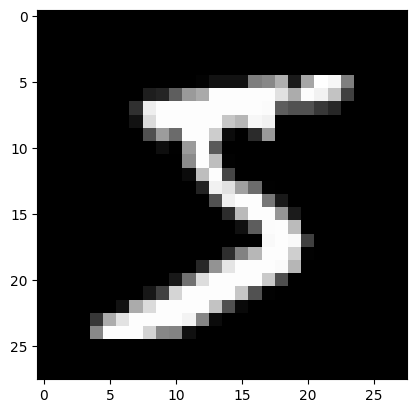

In [37]:
plt.imshow(x_train[0], cmap='gray')

In [38]:
y_train[0]

np.uint8(5)

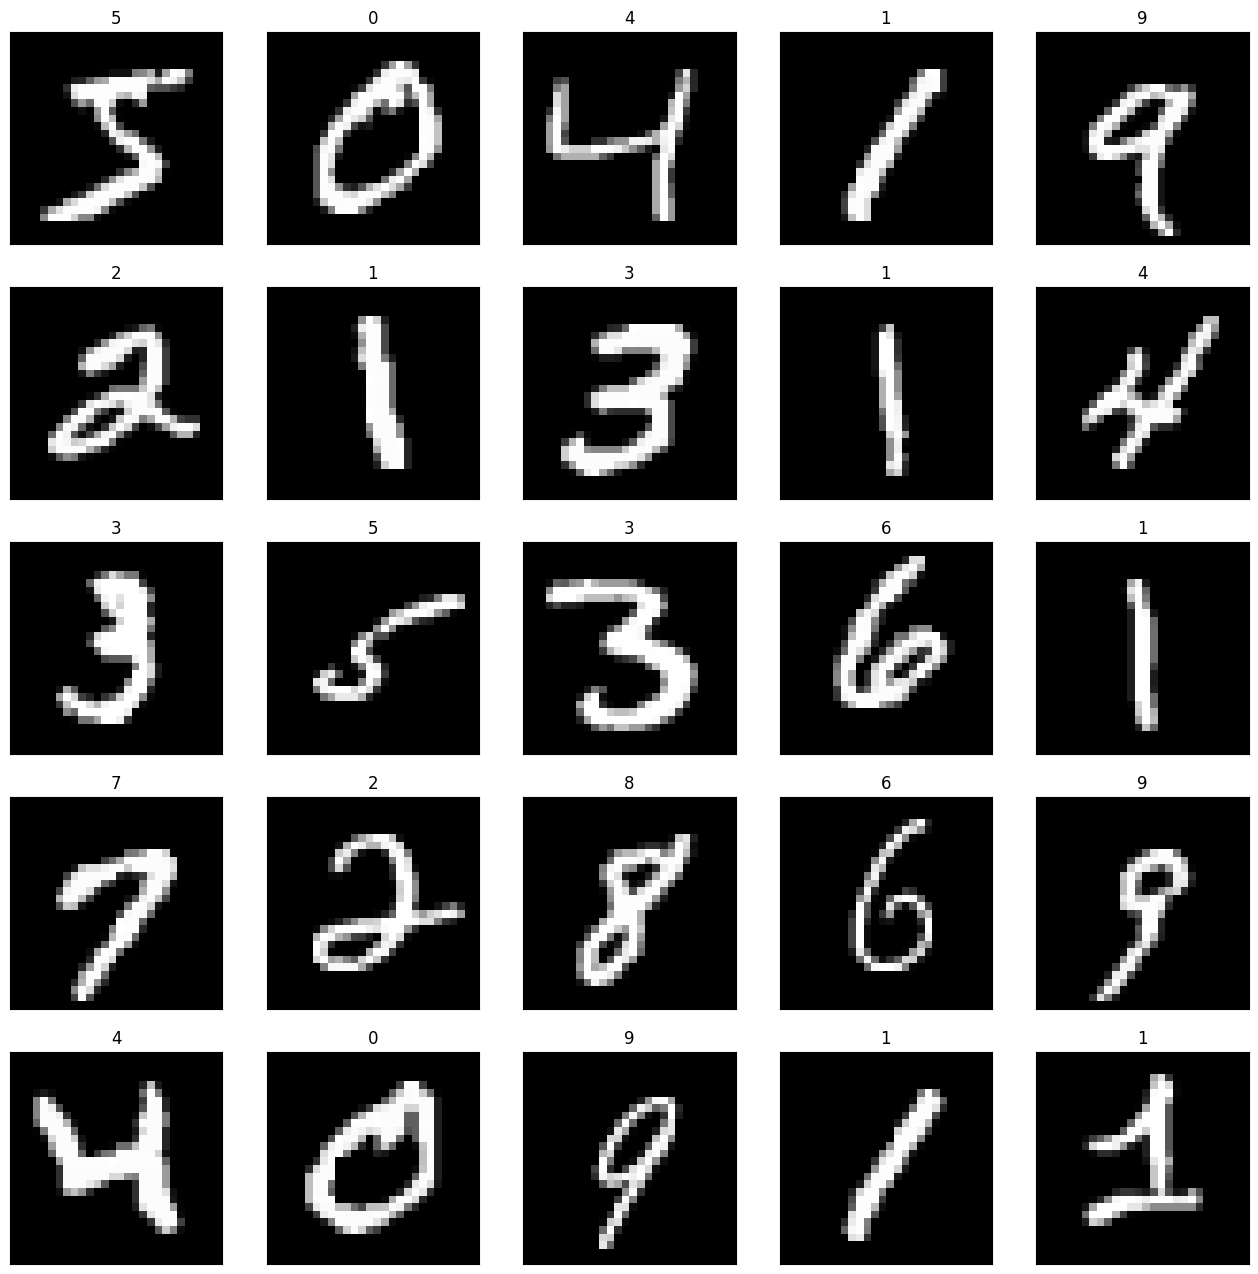

In [39]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.xticks([]); plt.yticks([])

In [40]:
import seaborn as sns

<Axes: xlabel='count'>

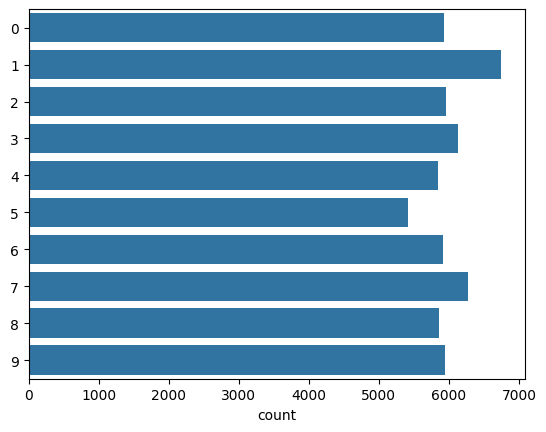

In [41]:
sns.countplot(y=y_train)

In [42]:
# Normalize

x_train = x_train/255
x_test = x_test/255

In [43]:
x_train[0].shape

(28, 28)

In [44]:
x_train[0].size

784

#### Building the Model

In [45]:
from keras.layers import Conv2D, MaxPool2D, Flatten

In [46]:
model = Sequential()

model.add(Input(shape=(28, 28, 1)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [47]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,258 (122.10 KB)

 Trainable params: 31,258 (122.10 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

#### Train the Model

In [49]:
model.fit(x_train, y_train, epochs=10, batch_size=10)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - accuracy: 0.9572 - loss: 0.1396
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9837 - loss: 0.0531
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9883 - loss: 0.0370
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9908 - loss: 0.0289
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9930 - loss: 0.0223
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9941 - loss: 0.0194
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - accuracy: 0.9950 - loss: 0.0157
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - accuracy: 0.9954 - loss: 0.0138
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - accuracy: 0.9959 - loss: 0.0117
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9967 - loss: 0.0100


In [50]:
model.evaluate(x_test, y_test, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9873 - loss: 0.0513


[0.05125785991549492, 0.9872999787330627]

#### Predict on New Image

In [58]:
# Predict on new image
img = cv2.imread('images/new-char1.jpg', 0)
img = cv2.resize(img, (28, 28))
thresh, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY_INV)
img = np.reshape(img, (1, 28, 28))
pred = model.predict(img, verbose=False)
print(pred.argmax())

5


In [59]:
# plt.imshow(img, cmap='gray')